Таблица 5. Доверительные интервалы (95%)
Параметр   | n = 20               | n = 100              | Истина
-----------------------------------------------------------------
mu         | [-0.62; 0.28] | [-0.24; 0.12] | 0
sigma      | [0.73; 1.40] | [0.81; 1.07] | 1

Таблица 6. Результат F-теста
F_набл     | F_крит     | Уровень alpha   | Решение
-------------------------------------------------------
1.0839908100518703 | 1.6925651552869265 | 0.05            | H0 принята


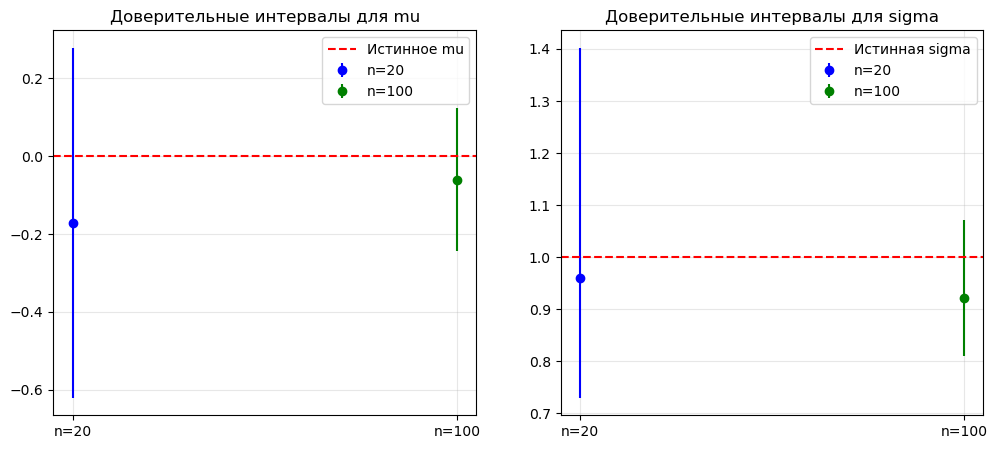

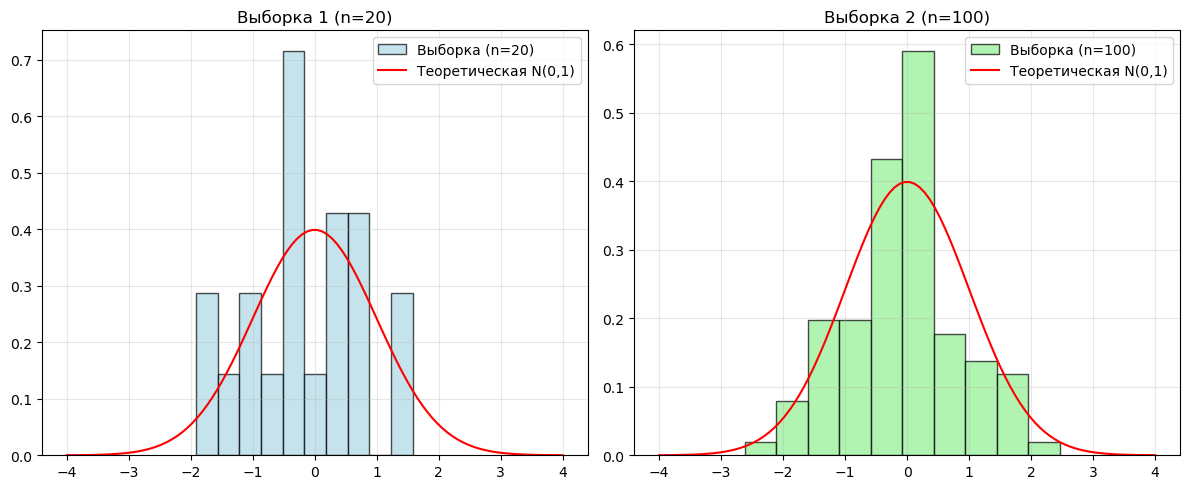

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# 1. Генерация выборок
n1, n2 = 20, 100
mu_true, sigma_true = 0, 1
sample1 = np.random.normal(mu_true, sigma_true, n1)
sample2 = np.random.normal(mu_true, sigma_true, n2)

def get_stats(data, alpha=0.05):
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    
    t_crit = stats.t.ppf(1 - alpha/2, n - 1)
    mu_ci = (mean - t_crit * (std / np.sqrt(n)), mean + t_crit * (std / np.sqrt(n)))
    
    chi2_low = stats.chi2.ppf(alpha/2, n - 1)
    chi2_high = stats.chi2.ppf(1 - alpha/2, n - 1)
    var_ci = ((n - 1) * std**2 / chi2_high, (n - 1) * std**2 / chi2_low)
    sigma_ci = (np.sqrt(var_ci[0]), np.sqrt(var_ci[1]))
    
    return mean, std, mu_ci, sigma_ci

stats1 = get_stats(sample1)
stats2 = get_stats(sample2)

s1_sq, s2_sq = stats1[1]**2, stats2[1]**2
f_obs = s1_sq / s2_sq if s1_sq > s2_sq else s2_sq / s1_sq
df1, df2 = (n1-1, n2-1) if s1_sq > s2_sq else (n2-1, n1-1)
alpha = 0.05
f_crit = stats.f.ppf(1 - alpha, df1, df2)
decision = "H0 принята" if f_obs < f_crit else "H0 отвергнута"

print("Таблица 5. Доверительные интервалы (95%)")
print(f"{'Параметр':<10} | {'n = 20':<20} | {'n = 100':<20} | {'Истина'}")
print("-" * 65)
print(f"{'mu':<10} | [{stats1[2][0]:.2f}; {stats1[2][1]:.2f}] | [{stats2[2][0]:.2f}; {stats2[2][1]:.2f}] | {mu_true}")
print(f"{'sigma':<10} | [{stats1[3][0]:.2f}; {stats1[3][1]:.2f}] | [{stats2[3][0]:.2f}; {stats2[3][1]:.2f}] | {sigma_true}")

print("\nТаблица 6. Результат F-теста")
print(f"{'F_набл':<10} | {'F_крит':<10} | {'Уровень alpha':<15} | {'Решение'}")
print("-" * 55)
print(f"{f_obs:<10} | {f_crit:<10} | {alpha:<15} | {decision}")


fig7, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(1, stats1[0], yerr=[[stats1[0]-stats1[2][0]], [stats1[2][1]-stats1[0]]], fmt='bo', label='n=20')
ax1.errorbar(2, stats2[0], yerr=[[stats2[0]-stats2[2][0]], [stats2[2][1]-stats2[0]]], fmt='go', label='n=100')
ax1.axhline(mu_true, color='red', linestyle='--', label='Истинное mu')
ax1.set_title("Доверительные интервалы для mu")
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['n=20', 'n=100'])
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.errorbar(1, stats1[1], yerr=[[stats1[1]-stats1[3][0]], [stats1[3][1]-stats1[1]]], fmt='bo', label='n=20')
ax2.errorbar(2, stats2[1], yerr=[[stats2[1]-stats2[3][0]], [stats2[3][1]-stats2[1]]], fmt='go', label='n=100')
ax2.axhline(sigma_true, color='red', linestyle='--', label='Истинная sigma')
ax2.set_title("Доверительные интервалы для sigma")
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['n=20', 'n=100'])
ax2.legend()
ax2.grid(True, alpha=0.3)

fig8, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))
x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x, 0, 1)

ax3.hist(sample1, density=True, color='lightblue', edgecolor='black', alpha=0.7, label='Выборка (n=20)')
ax3.plot(x, y, 'r-', label='Теоретическая N(0,1)')
ax3.set_title("Выборка 1 (n=20)")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.hist(sample2, density=True, color='lightgreen', edgecolor='black', alpha=0.7, label='Выборка (n=100)')
ax4.plot(x, y, 'r-', label='Теоретическая N(0,1)')
ax4.set_title("Выборка 2 (n=100)")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()